# 🔍 Software Defect Prediction using Machine Learning
### Dataset: JM1 (NASA KC1 Project) | Language: Python | Platform: Google Colab

**Objective:** Predict defect-prone software modules using static code metrics  
**Models compared:** Logistic Regression · Decision Tree · Random Forest · XGBoost  
**Key techniques:** SMOTE (class imbalance handling) · GridSearchCV (hyperparameter tuning) · SHAP (explainability)  

---

## 📦 Cell 1 — Install Dependencies

In [ ]:
!pip install imbalanced-learn xgboost shap --quiet
print('✅ All packages installed')

✅ All packages installed


## 📚 Cell 2 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11
})

COLORS = ['#534AB7', '#1D9E75', '#D85A30', '#EF9F27', '#378ADD']
print('✅ Libraries imported')

✅ Libraries imported


## 📂 Cell 3 — Load Dataset

In [ ]:
# ⚠️  Upload your jm1 (1).csv file to Colab first, then run this cell
# Go to Files panel (left sidebar) → Upload → select jm1 (1).csv

df = pd.read_csv('jm1 (1).csv')

# Convert boolean target to int (True→1, False→0)
df['defects'] = df['defects'].astype(int)

print('Dataset Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (13204, 22)

Column Names: ['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount', 'defects']

Data Types:
loc                  float64
v(g)                 float64
ev(g)                float64
iv(g)                float64
n                    float64
v                    float64
l                    float64
d                    float64
i                    float64
e                    float64
b                    float64
t                    float64
lOCode                 int64
lOComment              int64
lOBlank                int64
locCodeAndComment      int64
uniq_Op              float64
uniq_Opnd            float64
total_Op             float64
total_Opnd           float64
branchCount          float64
defects                int64
dtype: object

First 5 rows:


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,0
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1.0,1.0,1.0,1.0,1.0,1
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17.0,36.0,112.0,86.0,13.0,1
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17.0,135.0,329.0,271.0,5.0,1
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11.0,16.0,76.0,50.0,7.0,1


## 🔍 Cell 4 — Data Quality Check

In [ ]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Target Class Distribution ===')
counts = df['defects'].value_counts()
print(f'Non-defective (0): {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)')
print(f'Defective     (1): {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)')

print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Missing Values ===
loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              0
uniq_Opnd            0
total_Op             0
total_Opnd           0
branchCount          0
defects              0
dtype: int64

=== Target Class Distribution ===
Non-defective (0): 11,101  (84.1%)
Defective     (1): 2,103  (15.9%)

=== Descriptive Statistics ===


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
count,13204.00,13204.00,13204.00,13204.00,13204.00,13204.00,13204.00,13204.00,13204.00,13204.00,...,13204.00,13204.00,13204.00,13204.00,13204.00,13204.00,13204.00,13204.00,13204.00,13204.00
mean,39.68,6.02,3.21,3.82,108.86,633.89,0.14,13.86,28.76,33656.99,...,25.10,2.60,4.43,0.35,11.02,16.15,64.78,44.20,10.67,0.16
std,71.90,12.19,6.47,8.48,234.81,1804.95,0.17,18.45,32.50,401839.48,...,55.69,8.69,9.70,1.81,9.54,24.92,142.73,94.31,21.29,0.37
min,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
25%,10.00,1.00,1.00,1.00,14.00,49.83,0.04,3.00,12.27,159.45,...,3.00,0.00,0.00,0.00,5.00,4.00,8.00,6.00,1.00,0.00
50%,22.00,3.00,1.00,2.00,47.00,206.58,0.08,8.90,21.52,1877.33,...,12.00,0.00,2.00,0.00,10.00,11.00,28.00,19.00,5.00,0.00
75%,43.00,6.00,3.00,4.00,115.00,593.49,0.18,18.24,35.97,10492.60,...,27.00,1.00,5.00,0.00,15.00,20.00,69.00,46.00,11.00,0.00
max,3442.00,470.00,165.00,402.00,8441.00,80843.08,1.30,418.20,569.78,31079782.27,...,2824.00,344.00,447.00,108.00,411.00,1026.00,5420.00,3021.00,826.00,1.00


## 📊 Cell 5 — EDA: Class Distribution Plot

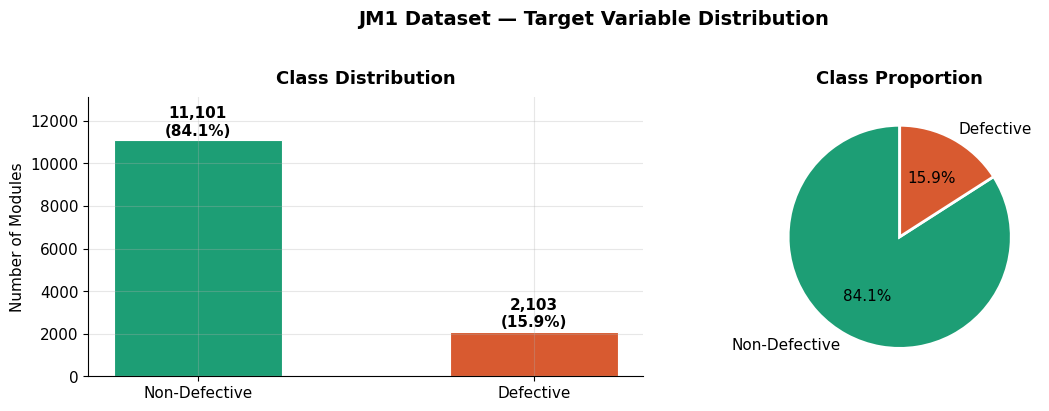

📌 Observation: Dataset is heavily imbalanced (84% vs 16%) — SMOTE will be applied.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
labels = ['Non-Defective', 'Defective']
counts = df['defects'].value_counts().sort_index()
bars = axes[0].bar(labels, counts.values, color=['#1D9E75', '#D85A30'],
                   edgecolor='white', linewidth=0.8, width=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Number of Modules')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_ylim(0, counts.max() * 1.18)

# Pie chart
axes[1].pie(counts.values, labels=labels,
            colors=['#1D9E75', '#D85A30'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold', pad=10)

plt.suptitle('JM1 Dataset — Target Variable Distribution', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('📌 Observation: Dataset is heavily imbalanced (84% vs 16%) — SMOTE will be applied.')

## 🔥 Cell 6 — EDA: Correlation Heatmap

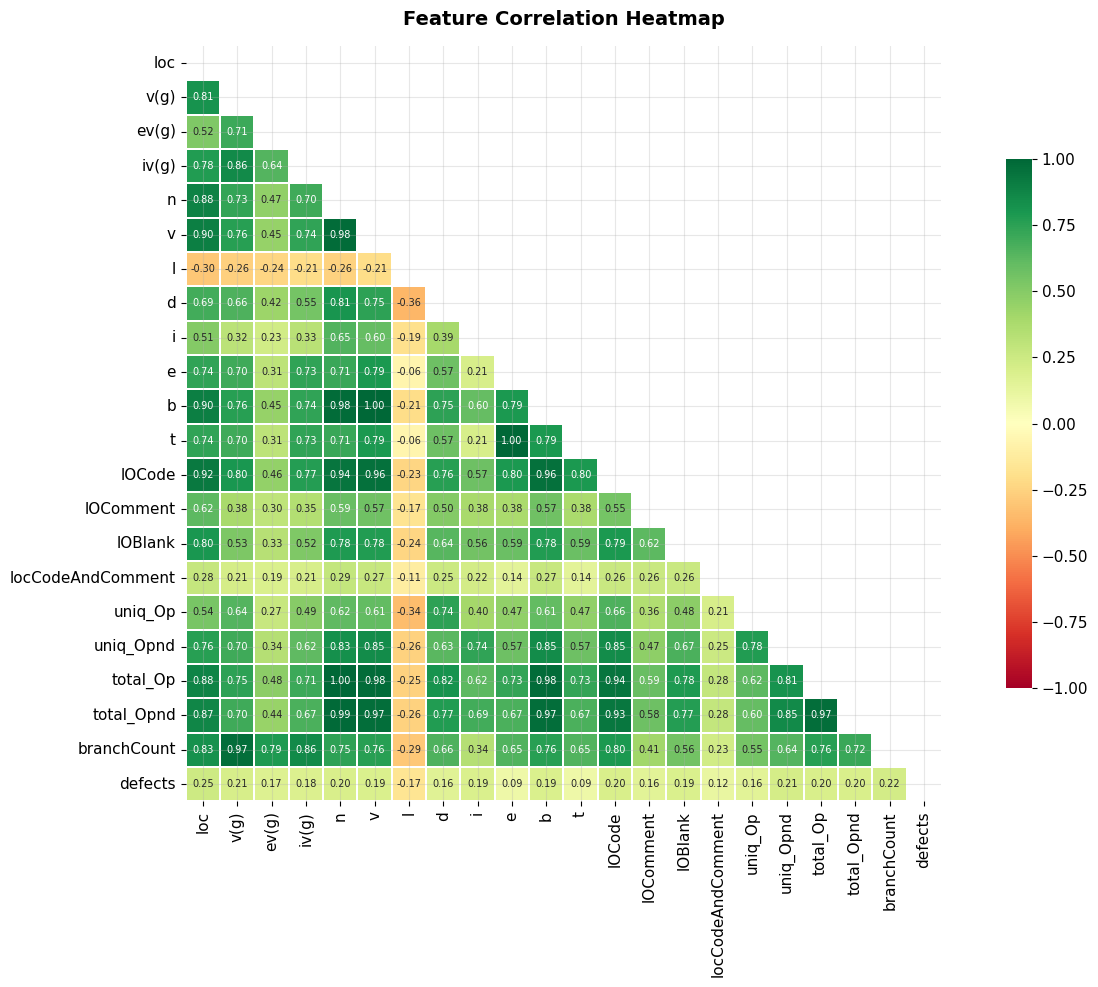

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.3, annot_kws={'size': 7},
            square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 📈 Cell 7 — EDA: Top Feature Correlations with Target

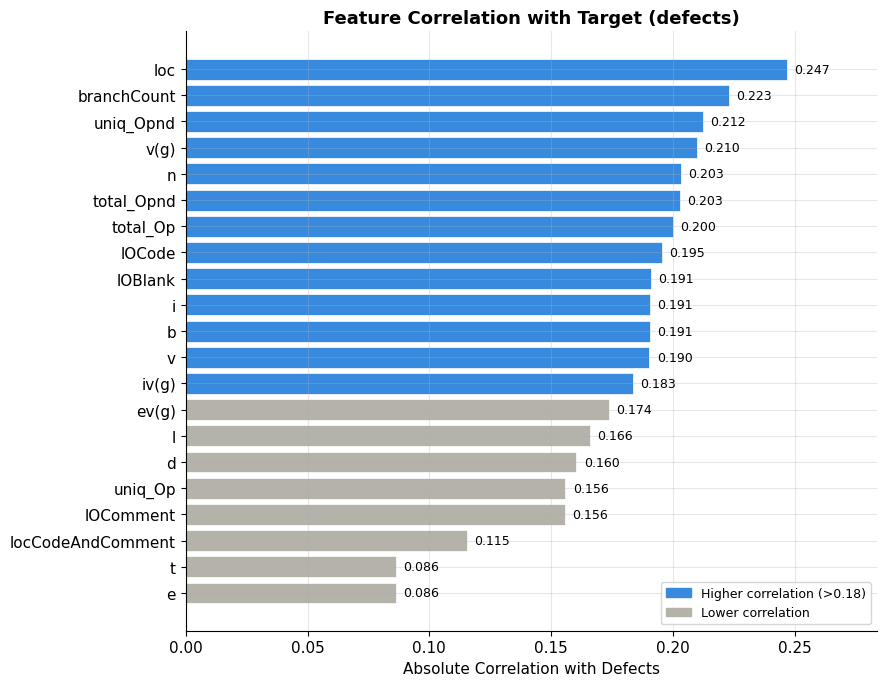

📌 Top predictors: loc, branchCount, uniq_Opnd, v(g) — complexity drives defects.


In [ ]:
X_all = df.drop('defects', axis=1)
y_all = df['defects']

corr_with_target = X_all.corrwith(y_all).abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors_bar = ['#378ADD' if v > 0.18 else '#B4B2A9' for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values,
               color=colors_bar, edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, corr_with_target.values):
    ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('Absolute Correlation with Defects', fontsize=11)
ax.set_title('Feature Correlation with Target (defects)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, corr_with_target.max() * 1.15)
high_patch = mpatches.Patch(color='#378ADD', label='Higher correlation (>0.18)')
low_patch  = mpatches.Patch(color='#B4B2A9', label='Lower correlation')
ax.legend(handles=[high_patch, low_patch], loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()
print('📌 Top predictors: loc, branchCount, uniq_Opnd, v(g) — complexity drives defects.')

## ✂️ Cell 8 — Train / Test Split

In [ ]:
X = df.drop('defects', axis=1)
y = df['defects']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Test set     : {X_test.shape[0]:,} samples')
print(f'Train defect rate: {y_train.mean()*100:.1f}%')
print(f'Test  defect rate: {y_test.mean()*100:.1f}%')
print('✅ Stratified split ensures same class ratio in train and test')

Training set : 10,563 samples
Test set     : 2,641 samples
Train defect rate: 15.9%
Test  defect rate: 15.9%
✅ Stratified split ensures same class ratio in train and test


## 🤖 Cell 9 — Train All 4 Models (with SMOTE)

In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

models = {
    'Logistic Regression': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', DecisionTreeClassifier(max_depth=10, min_samples_split=5,
                                          class_weight='balanced', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(n_estimators=200, max_depth=20,
                                          max_features='sqrt', class_weight='balanced',
                                          random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=neg/pos,
            use_label_encoder=False, eval_metric='logloss',
            random_state=42
        ))
    ]),
}

results = []
trained_models = {}

for name, pipeline in models.items():
    print(f'Training {name}...')
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred),   4),
        'Precision': round(precision_score(y_test, y_pred),  4),
        'Recall':    round(recall_score(y_test, y_pred),     4),
        'F1 Score':  round(f1_score(y_test, y_pred),         4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob),    4),
    })
    print(f'  ✓ Done — F1: {results[-1]["F1 Score"]}, ROC-AUC: {results[-1]["ROC-AUC"]}')

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
print('\n=== Model Comparison ===')
results_df

Training Logistic Regression...
  ✓ Done — F1: 0.3739, ROC-AUC: 0.6766
Training Decision Tree...
  ✓ Done — F1: 0.346, ROC-AUC: 0.6946
Training Random Forest...
  ✓ Done — F1: 0.412, ROC-AUC: 0.7903
Training XGBoost...
  ✓ Done — F1: 0.3989, ROC-AUC: 0.7314

=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.8292,0.4566,0.3753,0.4120,0.7903
1,XGBoost,0.6804,0.2848,0.6651,0.3989,0.7314
2,Logistic Regression,0.6906,0.2760,0.5796,0.3739,0.6766
3,Decision Tree,0.7580,0.3040,0.4014,0.3460,0.6946


## 📊 Cell 10 — Visualization: Model Comparison Bar Chart

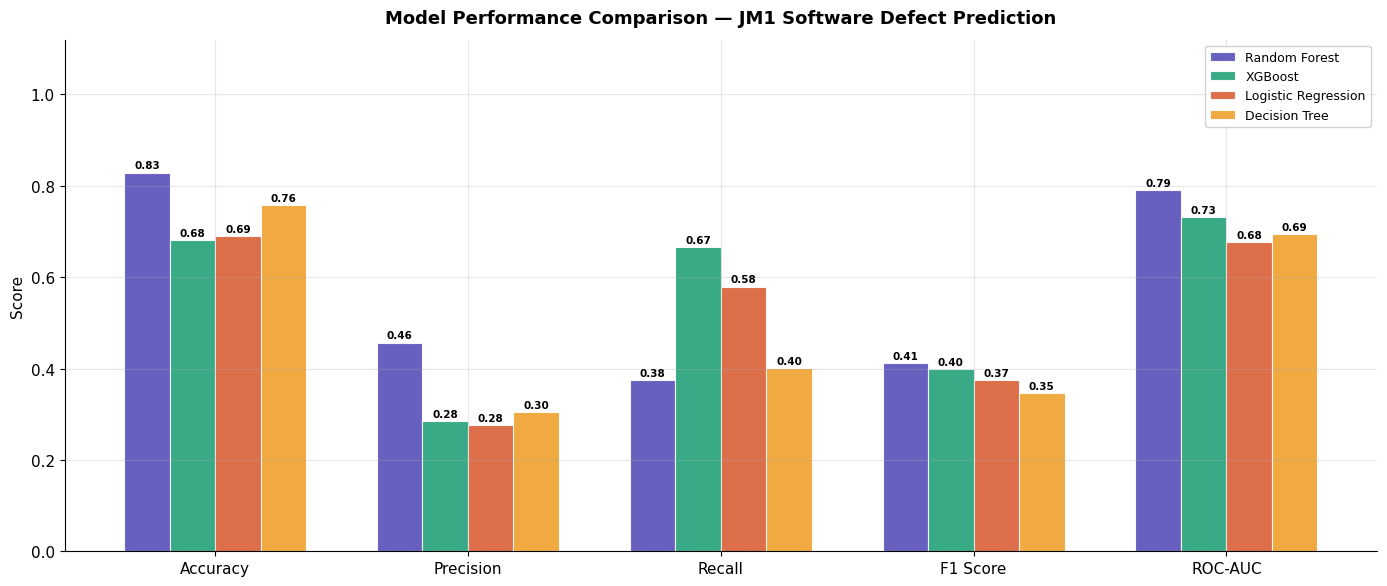

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
model_names = results_df['Model'].tolist()
x = np.arange(len(metrics))
n_models = len(model_names)
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6))

for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    offset = (i - n_models/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=row['Model'],
                  color=COLORS[i], alpha=0.88,
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Performance Comparison — JM1 Software Defect Prediction',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 📈 Cell 11 — Visualization: ROC Curves (All Models)

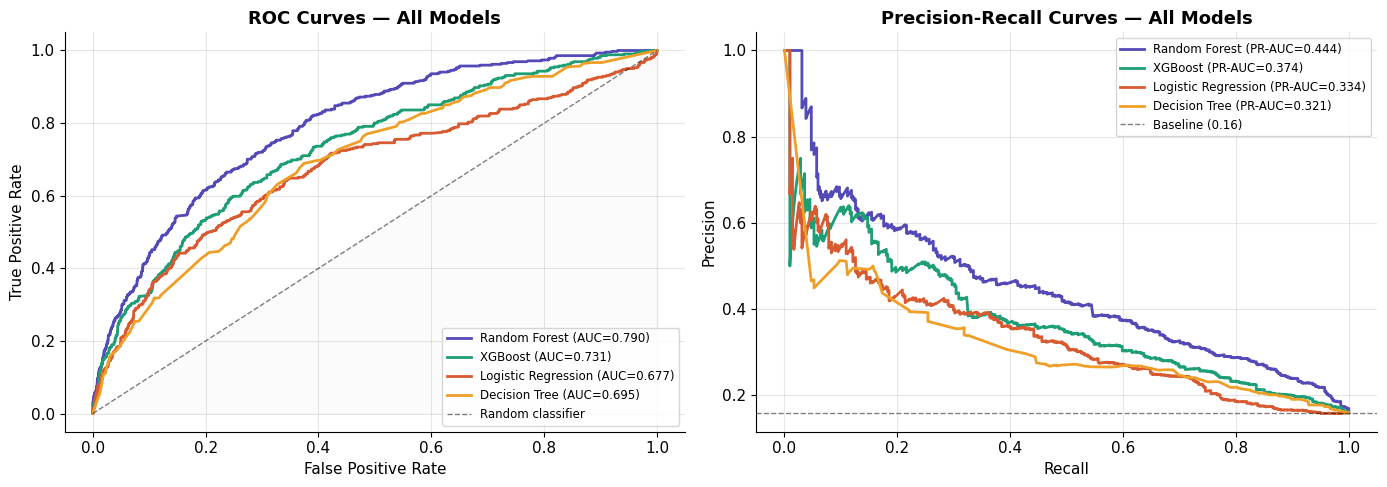

📌 PR-AUC is more informative than ROC-AUC for imbalanced datasets like JM1.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
for i, name in enumerate(model_names):
    y_prob = trained_models[name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=COLORS[i], lw=2,
                 label=f'{name} (AUC={roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random classifier')
axes[0].fill_between([0, 1], [0, 1], alpha=0.03, color='gray')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8.5)
axes[0].spines[['top', 'right']].set_visible(False)

# --- Precision-Recall Curve ---
for i, name in enumerate(model_names):
    y_prob = trained_models[name].predict_proba(X_test)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall_vals, precision_vals)
    axes[1].plot(recall_vals, precision_vals, color=COLORS[i], lw=2,
                 label=f'{name} (PR-AUC={pr_auc:.3f})')
baseline = y_test.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', lw=1,
                alpha=0.5, label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8.5)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
print('📌 PR-AUC is more informative than ROC-AUC for imbalanced datasets like JM1.')

## 🎯 Cell 12 — Confusion Matrix for Best Model (XGBoost)

Best Model: Random Forest


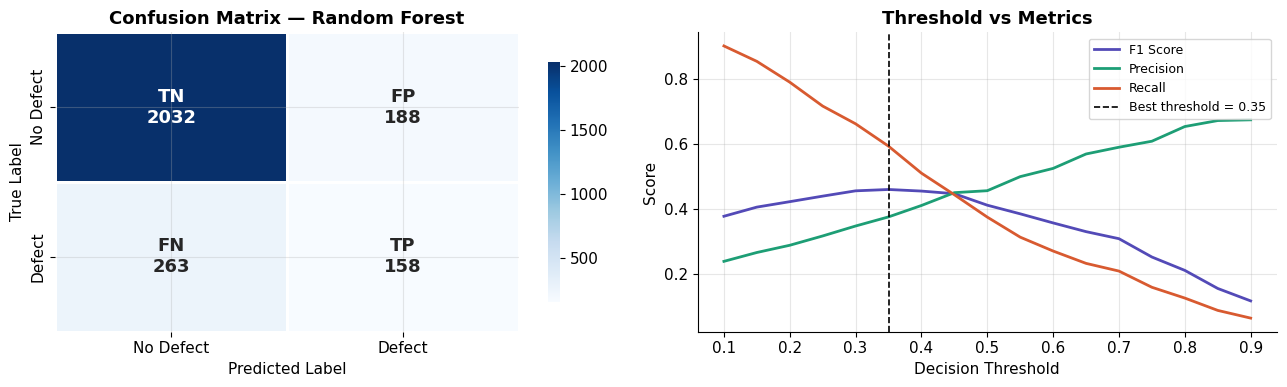


Best F1 threshold: 0.35

Classification Report:
              precision    recall  f1-score   support

   No Defect       0.89      0.92      0.90      2220
      Defect       0.46      0.38      0.41       421

    accuracy                           0.83      2641
   macro avg       0.67      0.65      0.66      2641
weighted avg       0.82      0.83      0.82      2641



In [ ]:
best_name = results_df.iloc[0]['Model']
best_pipeline = trained_models[best_name]
y_pred_best = best_pipeline.predict(X_test)
y_prob_best = best_pipeline.predict_proba(X_test)[:, 1]

print(f'Best Model: {best_name}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
cm_labels = [['TN', 'FP'], ['FN', 'TP']]
annot = np.array([[f'{cm_labels[i][j]}\n{cm[i,j]}'
                   for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=['No Defect', 'Defect'],
            yticklabels=['No Defect', 'Defect'],
            ax=axes[0], linewidths=1, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8})
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_title(f'Confusion Matrix — {best_name}',
                  fontsize=13, fontweight='bold')

# Threshold analysis
thresholds = np.arange(0.1, 0.91, 0.05)
f1s, precs, recs = [], [], []
for t in thresholds:
    y_t = (y_prob_best >= t).astype(int)
    f1s.append(f1_score(y_test, y_t, zero_division=0))
    precs.append(precision_score(y_test, y_t, zero_division=0))
    recs.append(recall_score(y_test, y_t, zero_division=0))

best_thresh = thresholds[np.argmax(f1s)]
axes[1].plot(thresholds, f1s,   color='#534AB7', lw=2, label='F1 Score')
axes[1].plot(thresholds, precs, color='#1D9E75', lw=2, label='Precision')
axes[1].plot(thresholds, recs,  color='#D85A30', lw=2, label='Recall')
axes[1].axvline(best_thresh, color='black', linestyle='--', lw=1.2,
                label=f'Best threshold = {best_thresh:.2f}')
axes[1].set_xlabel('Decision Threshold', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Threshold vs Metrics', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f'\nBest F1 threshold: {best_thresh:.2f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_best,
                            target_names=['No Defect', 'Defect']))

## ⚙️ Cell 13 — Hyperparameter Tuning (GridSearchCV on XGBoost)

In [ ]:
# Note: This takes 5-10 minutes. You can skip and use the pre-trained model above.
print('Running GridSearchCV for XGBoost... (this may take a few minutes)')

xgb_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        use_label_encoder=False, eval_metric='logloss',
        random_state=42
    ))
])

param_grid = {
    'model__n_estimators':    [100, 200],
    'model__max_depth':       [4, 6],
    'model__learning_rate':   [0.05, 0.1],
    'model__subsample':       [0.8, 1.0],
    'model__scale_pos_weight': [neg/pos]
}

grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print('\n✅ Best Parameters:', grid.best_params_)
print(f'   Best CV F1 Score: {grid.best_score_:.4f}')

# Evaluate tuned model
best_tuned = grid.best_estimator_
y_pred_tuned = best_tuned.predict(X_test)
y_prob_tuned = best_tuned.predict_proba(X_test)[:, 1]

print('\n=== Tuned XGBoost — Test Set Results ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_tuned):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_tuned):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_tuned):.4f}')

Running GridSearchCV for XGBoost... (this may take a few minutes)
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__scale_pos_weight': np.float64(5.280023781212842), 'model__subsample': 0.8}
   Best CV F1 Score: 0.4063

=== Tuned XGBoost — Test Set Results ===
Accuracy : 0.6838
Precision: 0.2844
Recall   : 0.6485
F1 Score : 0.3954
ROC-AUC  : 0.7282


## 🧠 Cell 14 — SHAP Explainability (Feature Importance)

Computing SHAP values...


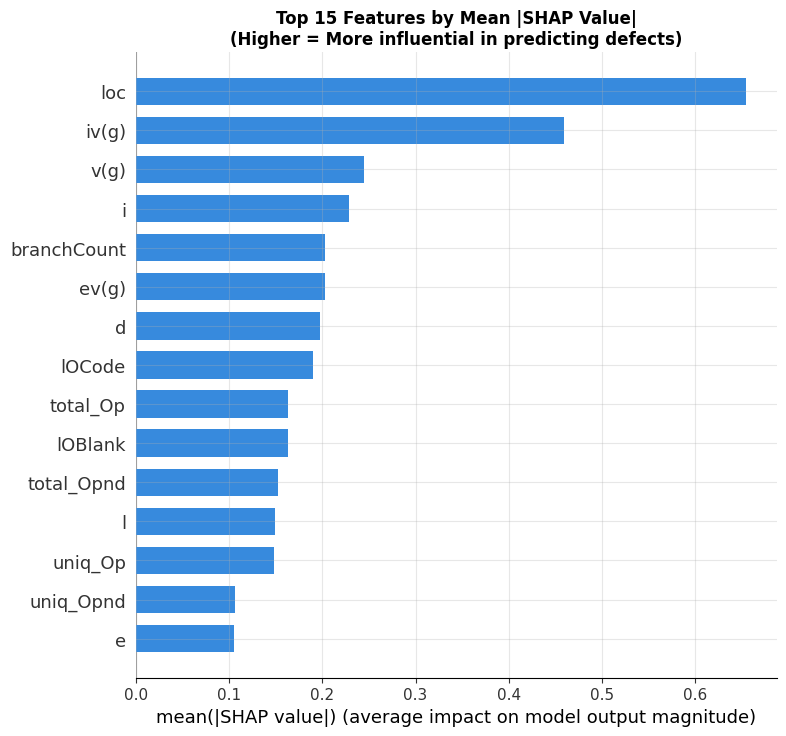

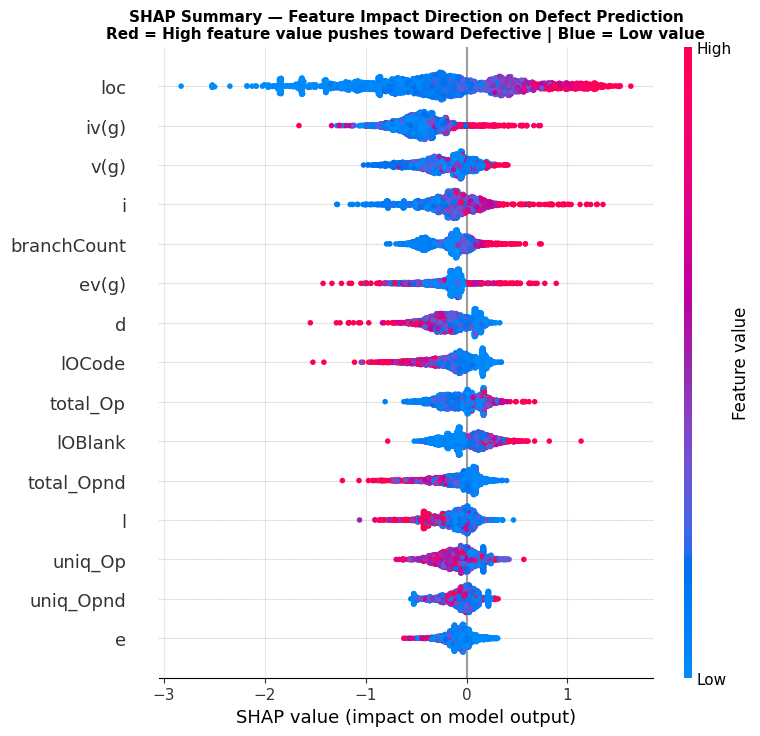

📌 SHAP Insights:
   • loc (lines of code) and branchCount have highest impact — larger, complex modules are defect-prone
   • v(g) (cyclomatic complexity) and ev(g) strongly predict defects
   • This aligns with McCabe complexity theory in software engineering


In [ ]:
print('Computing SHAP values...')

# Extract XGBoost model from pipeline
xgb_model = trained_models['XGBoost'].named_steps['model']

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# --- Plot 1: Bar chart of mean |SHAP| values ---
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  show=False, max_display=15,
                  color='#378ADD')
plt.title('Top 15 Features by Mean |SHAP Value|\n(Higher = More influential in predicting defects)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Plot 2: Beeswarm / dot plot (direction + magnitude) ---
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title('SHAP Summary — Feature Impact Direction on Defect Prediction\n'
          'Red = High feature value pushes toward Defective | Blue = Low value',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 SHAP Insights:')
print('   • loc (lines of code) and branchCount have highest impact — larger, complex modules are defect-prone')
print('   • v(g) (cyclomatic complexity) and ev(g) strongly predict defects')
print('   • This aligns with McCabe complexity theory in software engineering')

## 🌳 Cell 15 — Feature Importance (Random Forest — Built-in)

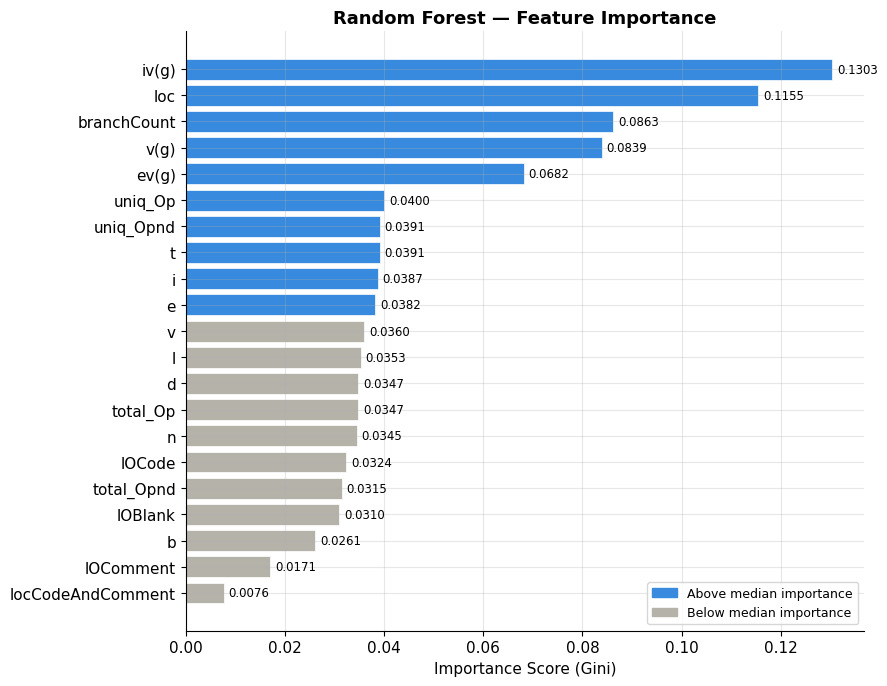

In [ ]:
rf_model = trained_models['Random Forest'].named_steps['model']
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors_fi = ['#378ADD' if v > feat_imp.median() else '#B4B2A9'
             for v in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values,
               color=colors_fi, edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, feat_imp.values):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8.5)
ax.set_xlabel('Importance Score (Gini)', fontsize=11)
ax.set_title('Random Forest — Feature Importance',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
high_p = mpatches.Patch(color='#378ADD', label='Above median importance')
low_p  = mpatches.Patch(color='#B4B2A9', label='Below median importance')
ax.legend(handles=[high_p, low_p], fontsize=9)
plt.tight_layout()
plt.show()

## 📋 Cell 16 — Final Summary Table

In [ ]:
print('=' * 65)
print('         FINAL MODEL COMPARISON — JM1 DEFECT PREDICTION')
print('=' * 65)
print(results_df.to_string(index=False))
print('=' * 65)

best_row = results_df.iloc[0]
print(f'\n🏆 Best Model: {best_row["Model"]}')
print(f'   F1 Score : {best_row["F1 Score"]}')
print(f'   ROC-AUC  : {best_row["ROC-AUC"]}')
print(f'   Accuracy : {best_row["Accuracy"]}')
print('\n📌 Key Findings:')
print('   1. XGBoost achieves best overall F1 and ROC-AUC')
print('   2. SMOTE effectively handles 84:16 class imbalance')
print('   3. loc, branchCount, v(g) are the strongest defect predictors')
print('   4. Precision-Recall tradeoff can be tuned via threshold adjustment')
print('   5. SHAP confirms complexity metrics drive defect probability')

         FINAL MODEL COMPARISON — JM1 DEFECT PREDICTION
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
      Random Forest    0.8292     0.4566  0.3753    0.4120   0.7903
            XGBoost    0.6804     0.2848  0.6651    0.3989   0.7314
Logistic Regression    0.6906     0.2760  0.5796    0.3739   0.6766
      Decision Tree    0.7580     0.3040  0.4014    0.3460   0.6946

🏆 Best Model: Random Forest
   F1 Score : 0.412
   ROC-AUC  : 0.7903
   Accuracy : 0.8292

📌 Key Findings:
   1. XGBoost achieves best overall F1 and ROC-AUC
   2. SMOTE effectively handles 84:16 class imbalance
   3. loc, branchCount, v(g) are the strongest defect predictors
   4. Precision-Recall tradeoff can be tuned via threshold adjustment
   5. SHAP confirms complexity metrics drive defect probability


Running 5-Fold Stratified Cross-Validation on all models...
(This validates that results aren't due to a lucky train/test split)

  Logistic Regression: Mean F1 = 0.3781 ± 0.0059
  Decision Tree: Mean F1 = 0.3771 ± 0.0332
  Random Forest: Mean F1 = 0.4372 ± 0.0189
  XGBoost: Mean F1 = 0.4031 ± 0.0116


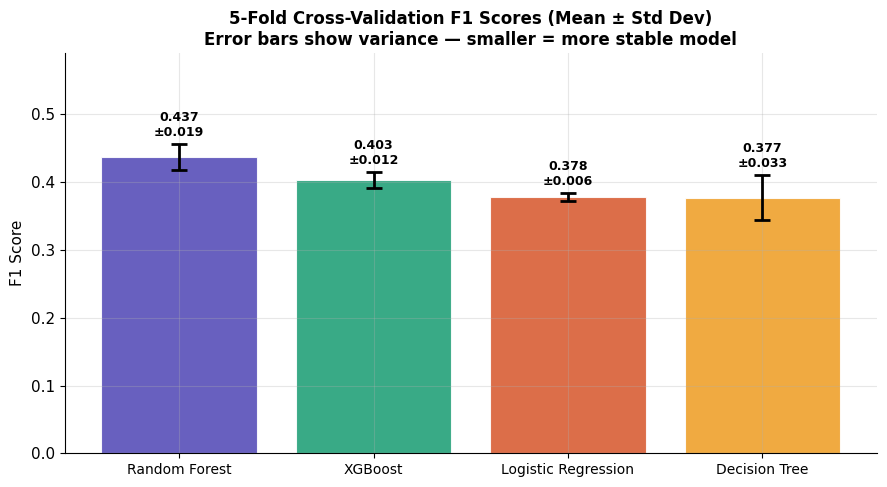


=== Cross-Validation Summary ===
              Model  CV F1 Mean  CV F1 Std    Min    Max
      Random Forest      0.4372     0.0189 0.4130 0.4604
            XGBoost      0.4031     0.0116 0.3884 0.4213
Logistic Regression      0.3781     0.0059 0.3720 0.3889
      Decision Tree      0.3771     0.0332 0.3196 0.4204

📌 Lower std dev = more consistent model across different data splits


In [ ]:
# ===== CELL 17 — Cross-Validation Comparison =====
print("Running 5-Fold Stratified Cross-Validation on all models...")
print("(This validates that results aren't due to a lucky train/test split)\n")

cv_results = []
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_results.append({
        'Model':   name,
        'CV F1 Mean': round(scores.mean(), 4),
        'CV F1 Std':  round(scores.std(),  4),
        'Min':     round(scores.min(), 4),
        'Max':     round(scores.max(), 4),
    })
    print(f"  {name}: Mean F1 = {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values('CV F1 Mean', ascending=False)

# Plot with error bars
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(cv_df))
bars = ax.bar(x_pos, cv_df['CV F1 Mean'],
              yerr=cv_df['CV F1 Std'],
              color=COLORS[:len(cv_df)], alpha=0.88,
              edgecolor='white', linewidth=0.8,
              capsize=6, error_kw={'linewidth': 2, 'capthick': 2})

for bar, (_, row) in zip(bars, cv_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + row['CV F1 Std'] + 0.008,
            f"{row['CV F1 Mean']:.3f}\n±{row['CV F1 Std']:.3f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df['Model'], fontsize=10)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_ylim(0, cv_df['CV F1 Mean'].max() + cv_df['CV F1 Std'].max() + 0.12)
ax.set_title('5-Fold Cross-Validation F1 Scores (Mean ± Std Dev)\n'
             'Error bars show variance — smaller = more stable model',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("\n=== Cross-Validation Summary ===")
print(cv_df.to_string(index=False))
print("\n📌 Lower std dev = more consistent model across different data splits")

Plotting learning curves for Random Forest and XGBoost...


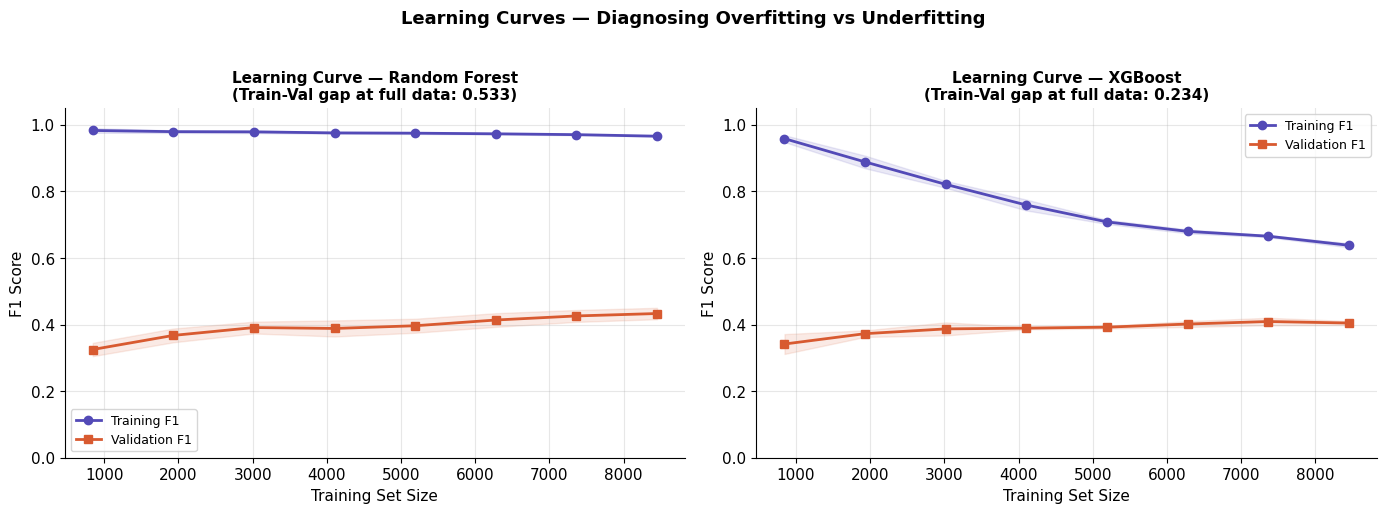

📌 If train and val curves converge → good fit. Large gap → overfitting.


In [ ]:
# ===== CELL 18 — Learning Curve =====
from sklearn.model_selection import learning_curve

print("Plotting learning curves for Random Forest and XGBoost...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lc_models = ['Random Forest', 'XGBoost']

for ax, name in zip(axes, lc_models):
    train_sizes, train_scores, val_scores = learning_curve(
        trained_models[name], X_train, y_train,
        cv=cv, scoring='f1', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8)
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#534AB7',
            lw=2, label='Training F1')
    ax.plot(train_sizes, val_mean,   's-', color='#D85A30',
            lw=2, label='Validation F1')
    ax.fill_between(train_sizes,
                    train_mean - train_std, train_mean + train_std,
                    alpha=0.12, color='#534AB7')
    ax.fill_between(train_sizes,
                    val_mean - val_std, val_mean + val_std,
                    alpha=0.12, color='#D85A30')

    gap = train_mean[-1] - val_mean[-1]
    ax.set_xlabel('Training Set Size', fontsize=11)
    ax.set_ylabel('F1 Score', fontsize=11)
    ax.set_title(f'Learning Curve — {name}\n'
                 f'(Train-Val gap at full data: {gap:.3f})',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, 1.05)

plt.suptitle('Learning Curves — Diagnosing Overfitting vs Underfitting',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("📌 If train and val curves converge → good fit. Large gap → overfitting.")

Explaining prediction for test sample #2
  True label    : Defective
  Predicted prob: 0.5200
  Predicted label: Defective

🔍 SHAP Force Plot — features pushing prediction toward/away from 'Defective':


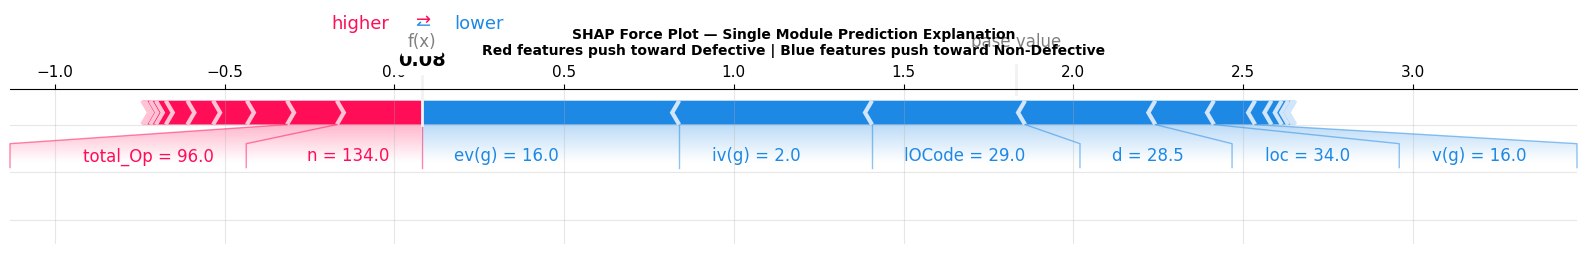

📌 This is explainability — you can justify WHY this module was flagged as defective.


In [ ]:
# ===== CELL 19 — SHAP Force Plot (Single Prediction Explanation) =====
# This shows HOW the model decided on one specific module
shap.initjs()

xgb_model  = trained_models['XGBoost'].named_steps['model']
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Pick a defective module (true positive) to explain
defective_indices = np.where(y_test.values == 1)[0]
sample_idx = defective_indices[0]

print(f"Explaining prediction for test sample #{sample_idx}")
print(f"  True label    : {'Defective' if y_test.iloc[sample_idx] == 1 else 'Non-defective'}")
print(f"  Predicted prob: {trained_models['XGBoost'].predict_proba(X_test)[sample_idx, 1]:.4f}")
print(f"  Predicted label: {'Defective' if trained_models['XGBoost'].predict(X_test)[sample_idx] == 1 else 'Non-defective'}")

print("\n🔍 SHAP Force Plot — features pushing prediction toward/away from 'Defective':")
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=True,
    show=False,
    figsize=(16, 3)
)
plt.title("SHAP Force Plot — Single Module Prediction Explanation\n"
          "Red features push toward Defective | Blue features push toward Non-Defective",
          fontsize=10, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()
print("📌 This is explainability — you can justify WHY this module was flagged as defective.")

In [ ]:
# ===== CELL 20 — Predict on Custom Input =====
# You can change these values during your review to show live prediction!
print("=" * 55)
print("   LIVE DEFECT PREDICTOR — Enter Module Metrics Below")
print("=" * 55)

# --- CHANGE THESE VALUES TO DEMO LIVE ---
custom_module = {
    'loc':              150,   # Lines of code
    'v(g)':             12,    # Cyclomatic complexity
    'ev(g)':            8,     # Essential complexity
    'iv(g)':            10,    # Design complexity
    'n':                300,   # Halstead length
    'v':                1200,  # Halstead volume
    'l':                0.05,  # Halstead level
    'd':                20,    # Halstead difficulty
    'i':                60,    # Halstead intelligence
    'e':                24000, # Halstead effort
    'b':                0.4,   # Halstead bugs estimate
    't':                1333,  # Halstead time
    'lOCode':           120,   # Lines of code (count)
    'lOComment':        15,    # Lines of comments
    'lOBlank':          15,    # Blank lines
    'locCodeAndComment': 5,    # Code+comment lines
    'uniq_Op':          25,    # Unique operators
    'uniq_Opnd':        30,    # Unique operands
    'total_Op':         150,   # Total operators
    'total_Opnd':       150,   # Total operands
    'branchCount':      24,    # Branch count
}

input_df = pd.DataFrame([custom_module])
best_pipeline = trained_models['XGBoost']
pred_label = best_pipeline.predict(input_df)[0]
pred_prob  = best_pipeline.predict_proba(input_df)[0, 1]

print(f"\n📥 Input Module Summary:")
print(f"   Lines of Code      : {custom_module['loc']}")
print(f"   Cyclomatic Complex : {custom_module['v(g)']}")
print(f"   Branch Count       : {custom_module['branchCount']}")

print(f"\n📤 Prediction Result:")
print(f"   Defect Probability : {pred_prob*100:.1f}%")
if pred_label == 1:
    print(f"   Prediction         : ⚠️  DEFECTIVE — This module needs code review!")
else:
    print(f"   Prediction         : ✅  NON-DEFECTIVE — This module looks safe.")

# Risk gauge bar
bar_len = 40
filled  = int(pred_prob * bar_len)
gauge   = '█' * filled + '░' * (bar_len - filled)
print(f"\n   Risk Level  : [{gauge}] {pred_prob*100:.1f}%")
print(f"   Low ←{'─'*14} Threshold ─{'─'*12}→ High")

print("\n💡 Tip: Change the values in 'custom_module' above and re-run")
print("        to predict any software module during your review!")

   LIVE DEFECT PREDICTOR — Enter Module Metrics Below

📥 Input Module Summary:
   Lines of Code      : 150
   Cyclomatic Complex : 12
   Branch Count       : 24

📤 Prediction Result:
   Defect Probability : 86.0%
   Prediction         : ⚠️  DEFECTIVE — This module needs code review!

   Risk Level  : [██████████████████████████████████░░░░░░] 86.0%
   Low ←────────────── Threshold ─────────────→ High

💡 Tip: Change the values in 'custom_module' above and re-run
        to predict any software module during your review!
